In [16]:
import tensorflow as tf
print(tf.keras.__version__)

3.13.2


In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Task 1: Data Preparation

Loading the Data

In [18]:
import zipfile, os

ZIP_PATH = "/content/drive/MyDrive/AI ml/Copy of devnagari digit"

# Define the directory to extract the contents to, or where data already resides
# This variable will be updated based on whether ZIP_PATH is a file or a directory
EXTRACT_DIR_BASE = "./devnagari_dataset"
os.makedirs(EXTRACT_DIR_BASE, exist_ok=True)

final_data_dir = None

if os.path.isfile(ZIP_PATH):
    # If ZIP_PATH is a file, assume it's a zip file and extract it
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_DIR_BASE)
    print(f"File '{os.path.basename(ZIP_PATH)}' unzipped to '{EXTRACT_DIR_BASE}'")
    final_data_dir = EXTRACT_DIR_BASE
elif os.path.isdir(ZIP_PATH):
    # If ZIP_PATH is a directory, assume the data is already extracted there
    print(f"'{ZIP_PATH}' is a directory. Assuming data is already extracted here.")
    final_data_dir = ZIP_PATH
else:
    print(f"Error: '{ZIP_PATH}' is neither a file nor a directory. Please check the path.")

# Update EXTRACT_DIR to be used by subsequent cells
if final_data_dir:
    EXTRACT_DIR = final_data_dir
else:
    # Fallback to EXTRACT_DIR_BASE if final_data_dir could not be determined
    EXTRACT_DIR = EXTRACT_DIR_BASE

print(f"Data will be loaded from: '{EXTRACT_DIR}'")

'/content/drive/MyDrive/AI ml/Copy of devnagari digit' is a directory. Assuming data is already extracted here.
Data will be loaded from: '/content/drive/MyDrive/AI ml/Copy of devnagari digit'


Training set: (9452, 28, 28, 1), Labels: (9452, 10)
Testing set: (900, 28, 28, 1), Labels: (900, 10)


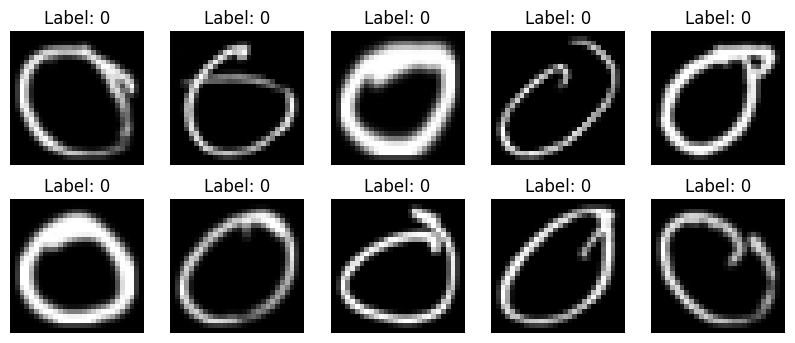

In [19]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from PIL import Image # Import Pillow


train_dir = os.path.join(EXTRACT_DIR, "DevanagariHandwrittenDigitDataset", "Train")
test_dir = os.path.join(EXTRACT_DIR, "DevanagariHandwrittenDigitDataset", "Test")

# Define image size
img_height, img_width = 28, 28

# Function to load images and labels using PIL
def load_images_from_folder(folder):
    images = []
    labels = []
    class_names = sorted(os.listdir(folder)) # Sorted class names (digit_0, digit_1, ...)
    class_map = {name: i for i, name in enumerate(class_names)} # Map class names to labels

    for class_name in class_names:
      class_path = os.path.join(folder, class_name)
      if not os.path.isdir(class_path): # Skip if not a directory
          continue
      label = class_map[class_name]
      for filename in os.listdir(class_path):
        img_path = os.path.join(class_path, filename)
        # Load image using PIL
        try:
          img = Image.open(img_path).convert("L")
        except:
          continue # Convert to grayscale
        img = img.resize((img_width, img_height)) # Resize to (28,28)
        img = np.array(img) / 255.0 # Normalize pixel values to [0,1]
        images.append(img)
        labels.append(label)
    return np.array(images), np.array(labels)

# Load training and testing datasets
x_train, y_train = load_images_from_folder(train_dir)
x_test, y_test = load_images_from_folder(test_dir)

# Reshape images for Keras input
x_train = x_train.reshape(-1, img_height, img_width, 1) # Shape (num_samples, 28, 28, 1)
x_test = x_test.reshape(-1, img_height, img_width, 1)

# One-hot encode labels
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

# Print dataset shape
print(f"Training set: {x_train.shape}, Labels: {y_train.shape}")
print(f"Testing set: {x_test.shape}, Labels: {y_test.shape}")

# Visualize some images
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {np.argmax(y_train[i])}")
    plt.axis("off")
plt.show() # Call plt.show() once after the loop to display all subplots

In [20]:
# Model parameters
import tensorflow as tf
from tensorflow import keras


num_classes = 10
input_shape = (28, 28, 1)
model = keras.Sequential(
[
keras.layers.Input(shape=input_shape),
keras.layers.Flatten(), # Flatten the 28x28 image to a 784-dimensional vector
keras.layers.Dense(64, activation="sigmoid"),
keras.layers.Dense(128, activation="sigmoid"),
keras.layers.Dense(256, activation="sigmoid"),
keras.layers.Dense(num_classes, activation="softmax"),
]
)

In [21]:
model.compile(
optimizer="adam",
loss="categorical_crossentropy", # Loss function for multi-class classification
metrics=["accuracy"] # Track accuracy during training
)

In [22]:
batch_size = 128
epochs = 20 # Changed epochs to 20 as suggested
# Callbacks
callbacks = [
    keras.callbacks.ModelCheckpoint(filepath="model_at_epoch_{epoch}.keras"),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=4 ),
]
# Train the model with callbacks and validation split
history = model.fit(
    x_train, # Ensure this is the Devnagari x_train
    y_train, # Ensure this is the Devnagari y_train
    batch_size=batch_size,
    epochs=epochs,
    validation_data=(x_test, y_test), # Changed validation_split to 0.2 as suggested
    callbacks=callbacks,
)

Epoch 1/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5346 - loss: 1.4628 - val_accuracy: 0.3467 - val_loss: 3.7497
Epoch 2/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9286 - loss: 0.3501 - val_accuracy: 0.5889 - val_loss: 3.6861
Epoch 3/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9712 - loss: 0.1183 - val_accuracy: 0.6144 - val_loss: 3.8177
Epoch 4/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9820 - loss: 0.0750 - val_accuracy: 0.6233 - val_loss: 3.9338
Epoch 5/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9862 - loss: 0.0549 - val_accuracy: 0.6067 - val_loss: 4.0355
Epoch 6/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9889 - loss: 0.0423 - val_accuracy: 0.6256 - val_loss: 4.1704


In [23]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"Test accuracy: {test_acc:.4f}")

29/29 - 0s - 3ms/step - accuracy: 0.6256 - loss: 4.1704
Test accuracy: 0.6256


In [24]:
model.save('mnist_fully_connected_model.h5')

In [25]:
loaded_model = tf.keras.models.load_model('mnist_fully_connected_model.h5')

In [26]:
# Predict on test data
predictions = model.predict(x_test)
# Convert predictions from probabilities to digit labels
predicted_labels = np.argmax(predictions, axis=1)
# Check the first prediction
print(f"Predicted label for first image: {predicted_labels[0]}")
print(f"True label for first image: {np.argmax(y_test[0])}")

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Predicted label for first image: 0
True label for first image: 0
